## Kunskapskontroll Kod uppgifter!

## Kap 1

11. I koden nedananvänder vi först test_size=0.2 och sedan test_size=0.25,
förklara varför det ger oss proportionerna 60-20-20.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test =train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val =train_test_split(X_train_full, y_train_full,
test_size=0.25, random_state=42)

I första delen har man test_size=20 som är 20% av total data som används för testdata.
X_train_full och Y_train_full kommer att innehålla 80% av den totala data, som är träningsdata.
x_test och y_test är då den del som test_size=20 är. 

I andra uppdelningen använder vi test_size=25 vilket betyder att du tar 75% av X_train_full och Y_train_full vilket är 80% av hela datan som användes i början. Då får vi 25% av 80% vilket är 20% av hela ursprungsdatan. 
Då får vi 60% av ursungliga datan som tränings data(X_train och Y_train)
20% valideringsdata (X_val och Y_val)
20% Testdata (X_test och Y_test) och detta är då från all data.  

# Kap 2

## Koduppgifter

8. Förklara vad koden nedan gör. Varför är det viktigt att kunna spara en
modell?


In [3]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from joblib import dump, load

X, y = make_regression(n_samples=20000, n_features=3,
noise=0.1)
model = LinearRegression().fit(X, y)
dump(model, "linear_model.joblib")
model_loaded = load("linear_model.joblib")
print(model_loaded.predict(X[:5]))

[-17.10380772 -74.7442479  205.22195779  60.91309331 344.18683437]


I denna kod hämtar vi make_regression som är skapar konstgjorda dataset som är designade för regressionproblem.Den skapar data som har en linjär relation mellan funktionerna och målvariablerna. Den används ofta för att snabbt skapa exempeldata för att testa och demonstrera maskininlärningsmodeller. Sen hämtar vi en funktion LinearRegression från Sklearn.linear_model som används för och skapa en linjär regressionsmodell. Linjäregression är en grundläggnde metod inom maskininlärning där en modell för säker prediktera nya värden baserat på en linjär relation mellan 2 värden oftast X och Y. Joblib är ett bibliotek som används för och spara python-objekt. Särskilt används det ihop med scikit. Dump är att man sparar en tränad modell till en fil och load är när man hämtar en sparad modell. 
Det är användbart att använda sig av de för att spara tid tex om man jobbar med stora dataset eller komplexa modeller. man kan också spara olika versioner av en modell och ladda en specifik modell i ett specifikt senario.


9. Denna uppgift består av flera steg enligt nedan.
a) Läs in datasetet “data_01.csv” med funktionen read_csv() från Pandas.
Funktionen returnerar en DataFrame.
b) Dela upp datasetet i X och y.
c) Dela upp datan ytterligare, i ett träning-, ett validering-, och ett testset
med train_test_split(). Låt 20% av datan vara testdata och 15% av
den återstående datan vara valideringsdata.
d) Träna två valfria regressionsmodeller (exempelvis LinearRegression och
DecisionTreeRegressor) på träningsdatan. Notera, i kapitel 3 kommer
vi lära oss mer om DecisionTreeRegressor.
e) Utvärdera modellerna på valideringsdatan.
f) Träna om den bäst presterande modellen på både tränings- och validerings
datan.
g) Utvärdera modellen på testdatan.
h) Träna om modellen på hela datasetet.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# 9. a) Läs in datasetet “data_01.csv” med funktionen read_csv() från Pandas. Funktionen returnerar en DataFrame.

df = pd.read_csv("data_01.csv")

# 9. b) Dela upp datasetet i X och y. X är features och y är target.

X = df.drop(columns='target')
y = df['target']

# 9. c) Dela upp datan ytterligare, i ett träning-, ett validering-, och ett testset med train_test_split(). 
# Låt 20% av datan vara testdata och 15% av den återstående datan vara valideringsdata.
# Den andra raden: X_train_full och y_train_full delas nu in i X_train, X_val, y_train och y_val. Träningsdatan och valideringsdatan är ihopslagna.

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

# 9. d) Träna två valfria regressionsmodeller (exempelvis LinearRegression och DecisionTreeRegressor) på träningsdatan.
# Jag har lagt till ElasticNet som en tredje modell bara för att experimentera.

lr = LinearRegression()
dtr = DecisionTreeRegressor(random_state=42)
en = ElasticNet(random_state=42)

lr.fit(X_train, y_train)
dtr.fit(X_train, y_train)
en.fit(X_train, y_train)

# 9. e) Utvärdera modellerna på valideringsdatan.

rmse_lr = root_mean_squared_error(y_val, lr.predict(X_val))
rmse_dtr = root_mean_squared_error(y_val, dtr.predict(X_val))
rmse_en = root_mean_squared_error(y_val, en.predict(X_val))

print(f"RMSE for Linear Regression: {rmse_lr:.2f}")
print(f"RMSE for Decision Tree Regression: {rmse_dtr:.2f}")
print(f"RMSE for Elastic Net: {rmse_en:.2f}")

# 9. f) Träna om den bäst presterande modellen på både tränings- och valideringsdatan.

if rmse_lr < rmse_dtr:
    best_model = LinearRegression()
    best_model_name = "Linear Regression"
else:
    best_model = DecisionTreeRegressor(random_state=42)
    best_model_name = "Decision Tree Regression"
    
best_model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val])) 

# 9. g) Utvärdera modellen på testdatan.

rmse_test = root_mean_squared_error(y_test, best_model.predict(X_test))

print(f"Best model is: {best_model_name}")
print(f"Test RMSE for the best model: {rmse_test:.2f}")

  # 9. h) Träna om modellen på hela datasetet.

best_model.fit(X, y)

# Verkligheten, prediktioner = best_model.predict(X)

new_data = np.array([1, 3, 5, 2, 1]).reshape(1, -1)
best_model.predict(new_data)

RMSE for Linear Regression: 3.59
RMSE for Decision Tree Regression: 99.36
RMSE for Elastic Net: 42.36
Best model is: Linear Regression
Test RMSE for the best model: 3.37


/home/opiee/data_science/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([788.34717131])

10. Datasetet “salary_dataset.csv” innehåller 29 observationer av personer.
YearsExperience är hur många år de arbetat, och Salary är deras lön.
a) Läs in datasetet “salary_dataset.csv” med pandas read_csv()-funktion
och dela upp i X och y. Avgör själv vilken variabel som ska vara den
beroende variabeln y.
b) Dela upp datasetet i träning- och testset. (Inget validerings-set alltså!)
c) Träna två regressionsmodeller med k-delad korsvalidering med
cross_validate()-funktionen från scikit-learn. Använd neg_root_mean_squared_error
som scoring. Välj själv hur många iterationer den ska göra genom hy
perparametern cv.
d) Utvärdera modellen som presterar bäst på testsetet.

Linear Regression CV RMSE: 5293.20
Decision Tree CV RMSE: 5611.58
Elastic Net CV RMSE: 5664.17
Best model is: Linear Regression
Test RMSE for the best model: 7059.04
Test R² for the best model: 0.90


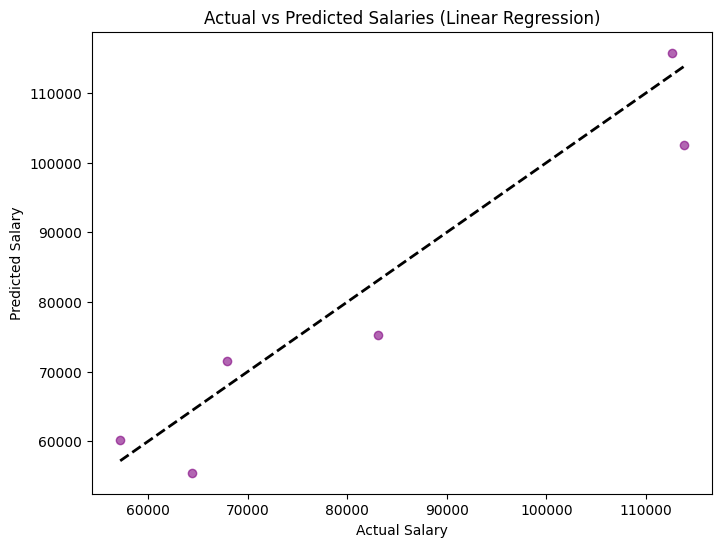

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset
df = pd.read_csv("salary_dataset.csv")

# 2. Split features and target
X = df.drop(columns='Salary')
y = df['Salary']

# 3. Split into training and test sets (80% train, 20% test)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Initialize models
model_lr = LinearRegression()
model_dtr = DecisionTreeRegressor(random_state=42)
model_enet = ElasticNet(random_state=42)

# 5. Cross-validation (5-fold) on training data
cv_lr = cross_validate(model_lr, X_train_full, y_train_full, cv=5, scoring='neg_root_mean_squared_error')
cv_dtr = cross_validate(model_dtr, X_train_full, y_train_full, cv=5, scoring='neg_root_mean_squared_error')
cv_enet = cross_validate(model_enet, X_train_full, y_train_full, cv=5, scoring='neg_root_mean_squared_error')

mean_rmse_lr = -np.mean(cv_lr['test_score'])
mean_rmse_dtr = -np.mean(cv_dtr['test_score'])
mean_rmse_enet = -np.mean(cv_enet['test_score'])

print(f"Linear Regression CV RMSE: {mean_rmse_lr:.2f}")
print(f"Decision Tree CV RMSE: {mean_rmse_dtr:.2f}")
print(f"Elastic Net CV RMSE: {mean_rmse_enet:.2f}")

# 6. Select the best model based on RMSE
if mean_rmse_lr < mean_rmse_dtr and mean_rmse_lr < mean_rmse_enet:
    best_model = model_lr
    best_model_name = "Linear Regression"
elif mean_rmse_dtr < mean_rmse_lr and mean_rmse_dtr < mean_rmse_enet:
    best_model = model_dtr
    best_model_name = "Decision Tree Regressor"
else:
    best_model = model_enet
    best_model_name = "Elastic Net"

print(f"Best model is: {best_model_name}")

# 7. Train the best model on the full training set
best_model.fit(X_train_full, y_train_full)

# 8. Ensure X_test has same columns as training
if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test, columns=X_train_full.columns)

# 9. Predict on test set
y_pred = best_model.predict(X_test)

# 10. Evaluate performance (manual RMSE for compatibility)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE for the best model: {rmse:.2f}")
print(f"Test R² for the best model: {r2:.2f}")

# 11. Visualize predictions
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='purple', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title(f'Actual vs Predicted Salaries ({best_model_name})')
plt.show()

11. I denna uppgift kommer vi arbeta med kategorisk data. Nominaldata är
kategorisk data där kategorierna inte har någon inbördes rangordning.

Datasetet mpg som följer med biblioteket seaborn är ett dataset med
398 observationer av bilar. Den beroende variabeln mpg står för miles
per gallon och beskriver bilarnas bränsleeffektivitet.

Om vi vill träna en regressionsmodell på mpg-datasetet behöver vi
hantera de två kategoriska variablerna origin och name. Variabeln
origin är en kategorisk variabel med tre olika värden: europe, ja
pan och usa. Den lämpar sig bra för one hot encoding. Variabeln
name har 305 unika värden. Skulle vi utföra one hot encoding på den
skulle vårt dataset få 305 nya dimensioner vilket inte är så lämpligt
i detta fall. Dessutom- tror du att namnet på bilen har något att gö
ra med hur långt den kör på en gallon bensin? Vi ska därför droppa
name-kolumnen innan vi börjar träna en modell på datan.

In [22]:
# a) Läs in datasetet “mpg” från Seaborn och skriv ut de första raderna.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

df = sns.load_dataset("mpg")
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [23]:
# b) droppa rader med saknade värden med dropna()-metoden.
df = df.dropna()

In [24]:
# c) Droppa kolumnen name.
df = df.drop(columns='name')

In [25]:
# d)Utför en dummy-variable-encoding på origin-kolumnenmed pandas
# get_dummies()-funktion. Ange drop_first=True så att vi får 2nya
# kolumneriställetför3.

df = pd.get_dummies(df, columns=['origin'], drop_first=True)

In [26]:
# e)Dela upp datasetet i X och y,med mpg som den beroende variabel ny.
X = df.drop(columns='mpg')
y = df['mpg']

In [27]:
# f)Dela upp datasetet i träning-och testset.
X_train_full, X_test, y_train_full, y_test =train_test_split(X, y, test_size=0.2, random_state=42)


In [28]:
# g)Träna en linjär regressionsmodell på träningsdatan och utvärdera den på
# testdatan.
model = LinearRegression()
model.fit(X_train_full, y_train_full)
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Test RMSE: {rmse:.2f}") 

Test RMSE: 3.26


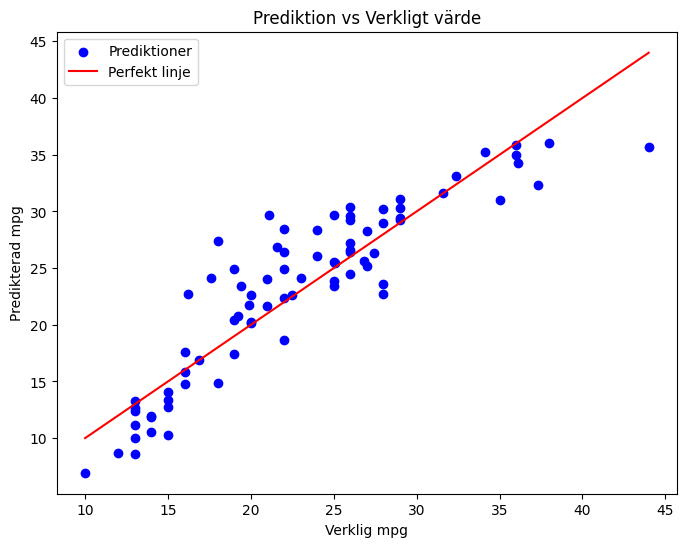

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot: verkligt vs predikterat
plt.scatter(y_test, y_pred, color="blue", label="Prediktioner")

# Perfekt linje (y=x)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", label="Perfekt linje")

plt.xlabel("Verklig mpg")
plt.ylabel("Predikterad mpg")
plt.title("Prediktion vs Verkligt värde")
plt.legend()
plt.show()

12. I avsnitt2.2“Ett kod exempel från början till slut-Huspriser i Kalifornien”
så gås ett komplett kodexempel igenom.På validerings datan fick vi RMSE
Random ForestRegression:52277.96578719621.Försök få ett bättre
resultat genomatt exempelvis justera hyperparametrar eller genomföra
variabel selektion.

In [78]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Läs in data
housing_orginal = pd.read_csv("housing.csv")

# Filtrera bort ISLAND
housing = housing_orginal[housing_orginal["ocean_proximity"] != "ISLAND"]

# Skapa dummyvariabler för ocean_proximity
housing = pd.get_dummies(housing, columns=["ocean_proximity"], dtype=int, prefix="dmy")

# Drop rows with missing values (för enkelhet)
housing = housing.dropna()

# Dela upp data
h_train_full, h_test = train_test_split(housing, test_size=0.2, random_state=40)
h_train, h_val = train_test_split(h_train_full, test_size=0.25, random_state=36)

# Skapa X och y
hx_train_full = h_train_full.drop(columns=["median_house_value"])
hy_train_full = h_train_full["median_house_value"]

hx_train = h_train.drop(columns=["median_house_value"])
yh_train = h_train["median_house_value"]

hx_val = h_val.drop(columns=["median_house_value"])
yh_val = h_val["median_house_value"]

hx_test = h_test.drop(columns=["median_house_value"])
yh_test = h_test["median_house_value"]

# Kolla former
print("hx_train_full.shape:", hx_train_full.shape)
print("hy_train_full.shape:", hy_train_full.shape)

hx_train_full.shape: (16342, 12)
hy_train_full.shape: (16342,)


In [79]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(hx_train, yh_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [101]:
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

start_time = time.time()
rf_reg = RandomForestRegressor(random_state=42)
hyperparam_grid = {"max_depth": [5, 10, 20, 30, None], "n_estimators": [100, 200, 300],"min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt"]}
grid_search = GridSearchCV(rf_reg, hyperparam_grid, scoring="neg_root_mean_squared_error", cv=5)
grid_search.fit(hx_train, yh_train)

end_time = time.time()

execution_time = end_time - start_time
print(f"GridSearchCV fitting time: {execution_time:.4f} seconds")

GridSearchCV fitting time: 1156.0756 seconds


In [102]:
print("Best hyperparameters from grid search:", grid_search.best_params_)
# pd.DataFrame(grid_search.cv_results_)

Best hyperparameters from grid search: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [103]:
lr_pred = lin_reg.predict(hx_val)
rf_pred = grid_search.best_estimator_.predict(hx_val)  

print("RMSE for Linear Regression:", root_mean_squared_error(yh_val, lr_pred))
print("RMSE for Random Forest:", root_mean_squared_error(yh_val, rf_pred))

RMSE for Linear Regression: 68047.0276233829
RMSE for Random Forest: 49754.8312945527


In [104]:
print(np.mean(yh_val))
print(root_mean_squared_error(yh_val, rf_pred)// np.mean(yh_val))

207165.881546745
0.0


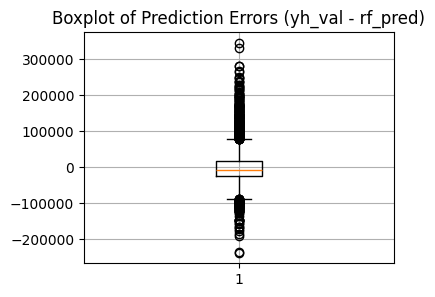

In [105]:
errors = yh_val - rf_pred

plt.figure(figsize=(4,3))
plt.boxplot(errors)
plt.title("Boxplot of Prediction Errors (yh_val - rf_pred)")
plt.grid(True) 

In [106]:
best_param = grid_search.best_params_
best_param

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [107]:
best_rf = RandomForestRegressor(**best_param)
best_rf.fit(hx_train, yh_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [108]:
best_rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [109]:
rf_pred_test = best_rf.predict(hx_test)
test_rmse = root_mean_squared_error(yh_test, rf_pred_test)
print(f"Test RMSE for the best Random Forest model: {test_rmse}")
print(rmse_test/np.mean(yh_test))

Test RMSE for the best Random Forest model: 49529.90874121579
1.6051927565032784e-05
